<class 'list'>
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - binary_accuracy: 0.7819 - loss: 0.5039 - val_binary_accuracy: 0.8724 - val_loss: 0.3679
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - binary_accuracy: 0.9009 - loss: 0.2997 - val_binary_accuracy: 0.8794 - val_loss: 0.3089
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - binary_accuracy: 0.9249 - loss: 0.2249 - val_binary_accuracy: 0.8764 - val_loss: 0.3045
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - binary_accuracy: 0.9410 - loss: 0.1795 - val_binary_accuracy: 0.8514 - val_loss: 0.3618
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - binary_accuracy: 0.9459 - loss: 0.1585 - val_binary_accuracy: 0.8773 - val_loss: 0.3050
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - binary_accuracy: 0.9611 - loss: 0.1266 - val_binary_accuracy: 0.8858 - val_loss: 0.2931
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - binary_accuracy: 0.9665 - loss: 0.1096 - val_binary_accuracy: 0.8846 - val_loss: 0.30

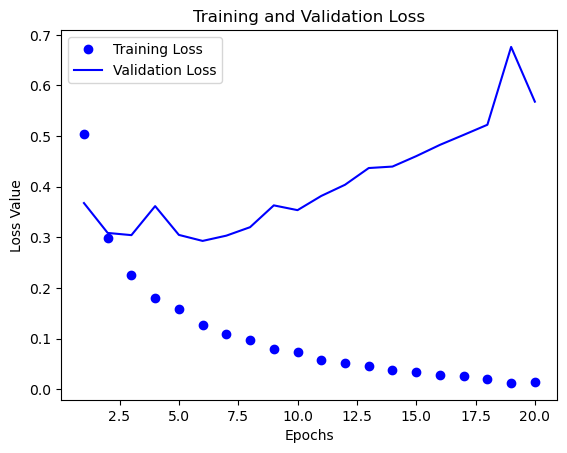

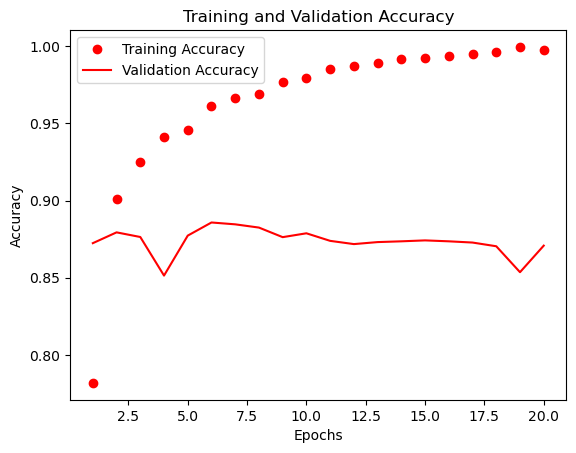

In [3]:
#Problem Statement:Binary classification using Deep Neural Networks Example: 
# Classify movie reviews into positive" reviews and "negative" reviews, 
# just based on the text content of the reviews. Use IMDB dataset.
!pip install tensorflow
#Load IMDB Dataset
from tensorflow.keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)
#Displays:encoded review
train_data[0]
#Labels
train_labels[0]
print(type([max(sequence) for sequence in train_data]))
max([max(sequence) for sequence in train_data])
#secure internet communication
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = ' '.join([reverse_word_index.get(i-3, '?') for i in train_data[0]])
decoded_review

#len of reveres word
len(reverse_word_index)

 #Vectorization
import numpy as np
def vectorize_sequences(sequences, dimension = 10000):
    results = np.zeros((len(sequences),dimension))
    for i,sequence in enumerate(sequences):
        results[i,sequence] = 1
    return results
#Convert Training/Test Data
xtrain = vectorize_sequences(train_data)
xtest = vectorize_sequences(test_data)

xtrain[0]
#Shape
xtrain.shape
#Convert Labels
ytrain = np.asarray(train_labels).astype('float32')
ytest = np.asarray(test_labels).astype('float32')

#Create Neural Network
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()

# ✅ Add Input layer first
model.add(layers.Input(shape=(10000,)))

model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

#Compile Model
from tensorflow.keras import optimizers
from tensorflow.keras import losses
from tensorflow.keras import metrics

model.compile(optimizer= optimizers.RMSprop(learning_rate= 0.001),
              loss = losses.binary_crossentropy,
              metrics= [metrics.binary_accuracy]) 
#Validation Set
xval = xtrain[:10000]
partial_xtrain = xtrain[10000:]

yval = ytrain[:10000]
partial_ytrain = ytrain[10000:]

#Train Model
history = model.fit(partial_xtrain,
                    partial_ytrain,
                    epochs=20,
                    batch_size= 512,
                    validation_data=(xval, yval))

# History object
# This object stores:
# loss values
# accuracy values
# validation metrics
# for every epoch.
history_dict = history.history
history_dict.keys()

import matplotlib.pyplot as plt
%matplotlib inline
#Plot training and validation Graph
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len(loss_values)+1)

plt.plot(epochs, loss_values, 'bo', label = "Training Loss")
plt.plot(epochs, val_loss_values, 'b', label = "Validation Loss")

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()

plt.show()

#acurracy graph
acc_values = history_dict['binary_accuracy']
val_acc_values = history_dict['val_binary_accuracy']

epochs = range(1, len(loss_values)+1)

plt.plot(epochs, acc_values, 'ro', label = "Training Accuracy")
plt.plot(epochs, val_acc_values, 'r', label = "Validation Accuracy")

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()